In [ ]:
# ============================================
# IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

In [ ]:
# ============================================
# LOAD DATASET
# ============================================

df = pd.read_csv("/sales.csv")
print(df)
print("Dataset Loaded Successfully")

              id        date  store_nbr                      family     sales  \
0              0  2013-01-01          1                  AUTOMOTIVE     0.000   
1              1  2013-01-01          1                   BABY CARE     0.000   
2              2  2013-01-01          1                      BEAUTY     0.000   
3              3  2013-01-01          1                   BEVERAGES     0.000   
4              4  2013-01-01          1                       BOOKS     0.000   
...          ...         ...        ...                         ...       ...   
3000883  3000883  2017-08-15          9                     POULTRY   438.133   
3000884  3000884  2017-08-15          9              PREPARED FOODS   154.553   
3000885  3000885  2017-08-15          9                     PRODUCE  2419.729   
3000886  3000886  2017-08-15          9  SCHOOL AND OFFICE SUPPLIES   121.000   
3000887  3000887  2017-08-15          9                     SEAFOOD    16.000   

         onpromotion  
0   

In [ ]:
# ============================================
# BASIC INFORMATION
# ============================================

print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Info:")
print(df.info())

   id        date  store_nbr      family  sales  onpromotion
0   0  2013-01-01          1  AUTOMOTIVE    0.0            0
1   1  2013-01-01          1   BABY CARE    0.0            0
2   2  2013-01-01          1      BEAUTY    0.0            0
3   3  2013-01-01          1   BEVERAGES    0.0            0
4   4  2013-01-01          1       BOOKS    0.0            0

Dataset Shape:
(3000888, 6)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB
None


In [ ]:
# ============================================
# DATA CLEANING
# ============================================

# Convert date column into datetime
df['date'] = pd.to_datetime(df['date'],errors='coerce')

In [ ]:
# Remove invalid dates
df = df.dropna(subset=['date'])

In [ ]:
# Remove duplicates
df.drop_duplicates(inplace=True)

In [ ]:
# Reset index
df.reset_index(drop=True,inplace=True)

In [ ]:
print("\nDataset Shape After Cleaning:")
print(df.shape)


Dataset Shape After Cleaning:
(3000888, 6)


In [ ]:
# ============================================
# MISSING VALUES
# ============================================

print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64


In [ ]:
# ============================================
# DAILY SALES AGGREGATION
# ============================================

daily_sales = df.groupby('date')['sales'].sum().reset_index()

print(daily_sales.head())

        date          sales
0 2013-01-01    2511.618999
1 2013-01-02  496092.417944
2 2013-01-03  361461.231124
3 2013-01-04  354459.677093
4 2013-01-05  477350.121229


In [ ]:
# ============================================
# 7-DAY MOVING AVERAGE
# ============================================

daily_sales['7_day_MA'] = daily_sales['sales'].rolling(window=7).mean()

print(daily_sales.head(10))

        date          sales       7_day_MA
0 2013-01-01    2511.618999            NaN
1 2013-01-02  496092.417944            NaN
2 2013-01-03  361461.231124            NaN
3 2013-01-04  354459.677093            NaN
4 2013-01-05  477350.121229            NaN
5 2013-01-06  519695.401088            NaN
6 2013-01-07  336122.801066  363956.181220
7 2013-01-08  318347.777981  409075.632504
8 2013-01-09  302530.809018  381423.974086
9 2013-01-10  258982.003049  366784.084361


In [ ]:
# ============================================
# 30-DAY MOVING AVERAGE
# ============================================

daily_sales['30_day_MA'] = daily_sales['sales'].rolling(window=30).mean()

print(daily_sales.head(35))

         date          sales       7_day_MA      30_day_MA
0  2013-01-01    2511.618999            NaN            NaN
1  2013-01-02  496092.417944            NaN            NaN
2  2013-01-03  361461.231124            NaN            NaN
3  2013-01-04  354459.677093            NaN            NaN
4  2013-01-05  477350.121229            NaN            NaN
5  2013-01-06  519695.401088            NaN            NaN
6  2013-01-07  336122.801066  363956.181220            NaN
7  2013-01-08  318347.777981  409075.632504            NaN
8  2013-01-09  302530.809018  381423.974086            NaN
9  2013-01-10  258982.003049  366784.084361            NaN
10 2013-01-11  289737.685085  357538.085502            NaN
11 2013-01-12  403258.212011  346953.527042            NaN
12 2013-01-13  464638.547998  339088.262315            NaN
13 2013-01-14  293348.362078  332977.628174            NaN
14 2013-01-15  299129.549954  330232.167027            NaN
15 2013-01-16  318347.913946  332491.753446            N

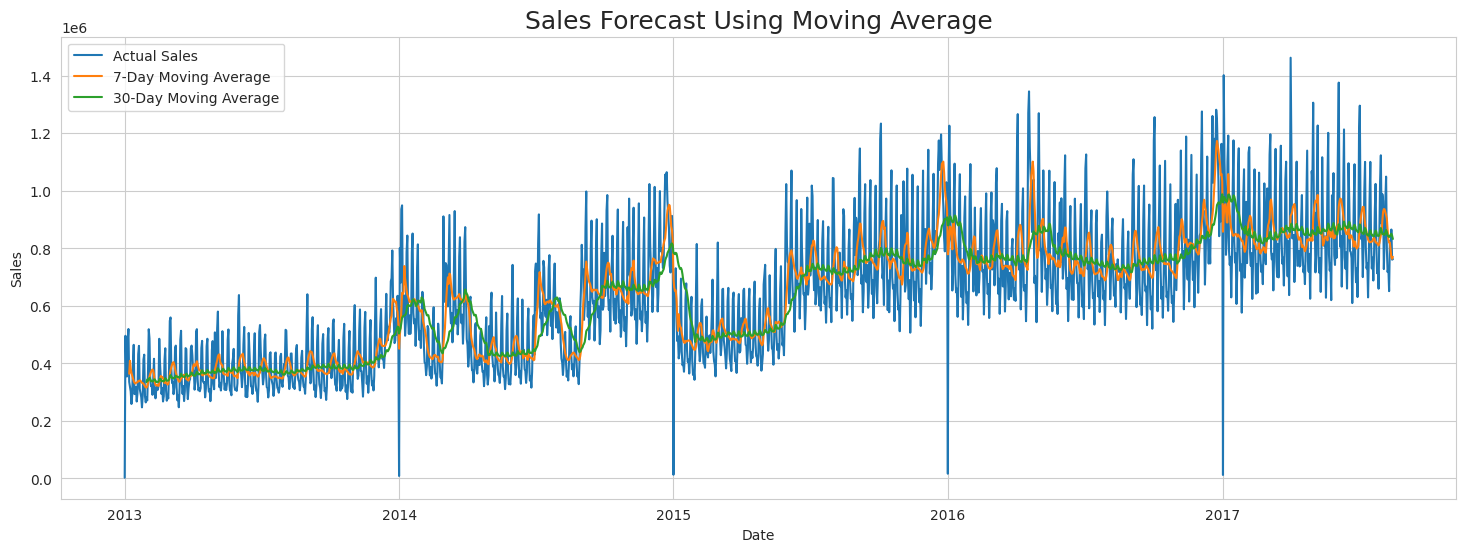

In [ ]:
# ============================================
# VISUALIZATION
# ============================================

plt.figure(figsize=(18,6))

# Actual Sales
plt.plot(daily_sales['date'],
         daily_sales['sales'],
         label='Actual Sales')

# Weekly Moving Average
plt.plot(daily_sales['date'],
         daily_sales['7_day_MA'],
         label='7-Day Moving Average')

# Monthly Moving Average
plt.plot(daily_sales['date'],
         daily_sales['30_day_MA'],
         label='30-Day Moving Average')

plt.title("Sales Forecast Using Moving Average",
          fontsize=18)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.show()

In [ ]:
# ============================================
# FORECAST COMPARISON
# ============================================

comparison = daily_sales[['date',
                          'sales',
                          '7_day_MA',
                          '30_day_MA']]

print(comparison.tail(20))

           date         sales       7_day_MA      30_day_MA
1664 2017-07-27  6.598498e+05  810036.845439  843314.654206
1665 2017-07-28  8.350997e+05  817562.757294  846754.744113
1666 2017-07-29  1.032311e+06  831764.017159  860138.046208
1667 2017-07-30  1.123752e+06  845973.122403  870854.024165
1668 2017-07-31  8.858568e+05  855872.052943  860131.588132
1669 2017-08-01  9.885278e+05  895150.071599  849869.872987
1670 2017-08-02  9.647120e+05  927158.496154  851188.826562
1671 2017-08-03  7.280685e+05  936904.018736  847712.466532
1672 2017-08-04  8.277757e+05  935857.733582  847161.602299
1673 2017-08-05  9.656937e+05  926340.988547  856008.990317
1674 2017-08-06  1.049559e+06  915741.943736  864134.552387
1675 2017-08-07  7.974650e+05  903114.532729  857438.478080
1676 2017-08-08  7.177663e+05  864434.330715  844669.578971
1677 2017-08-09  7.341397e+05  831495.424709  842335.606070
1678 2017-08-10  6.513869e+05  820540.914257  839697.344213
1679 2017-08-11  8.263737e+05  820340.63

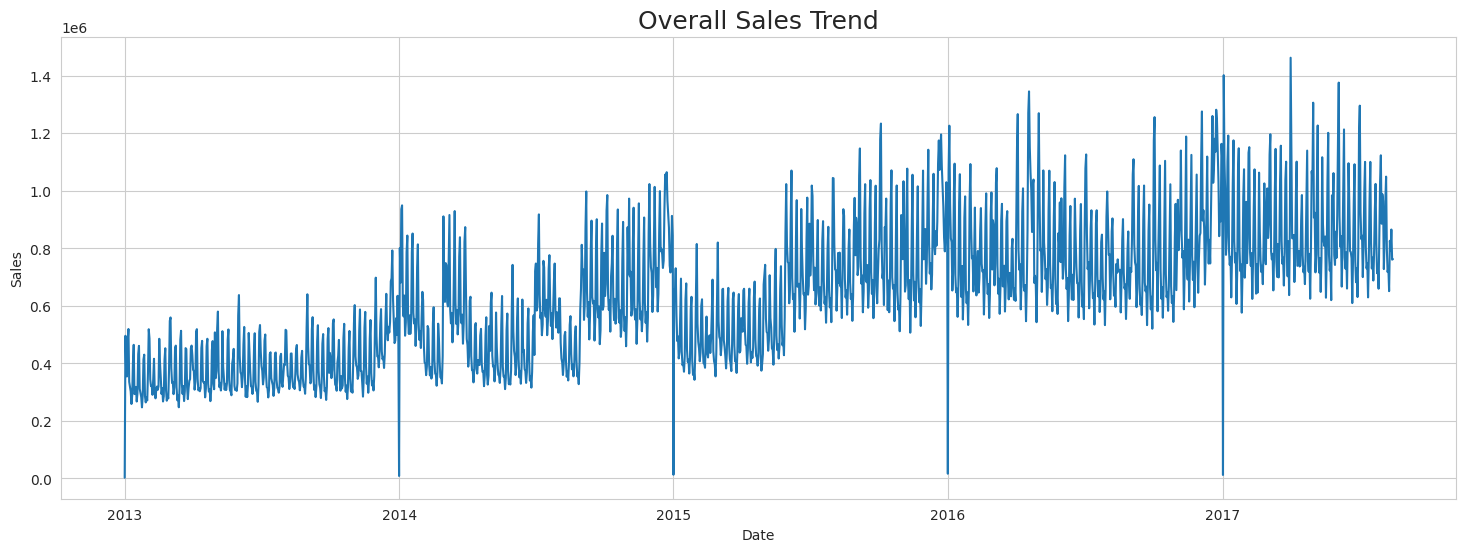

In [ ]:
# ============================================
# TREND LINE ANALYSIS
# ============================================

plt.figure(figsize=(18,6))

sns.lineplot(x='date',
             y='sales',
             data=daily_sales)

plt.title("Overall Sales Trend",
          fontsize=18)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

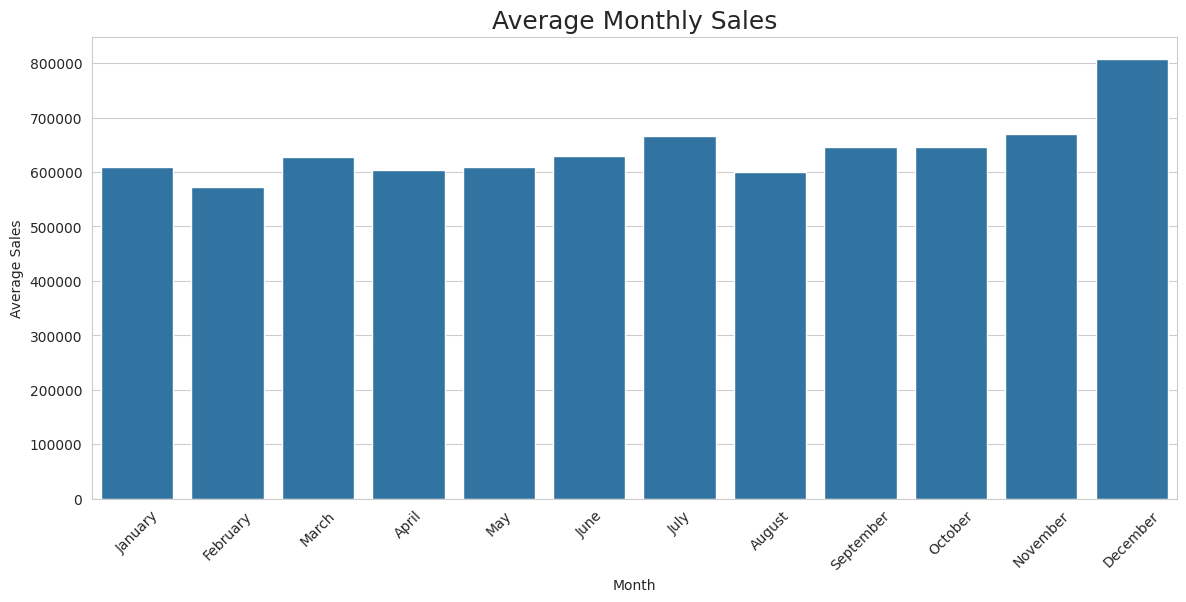

In [ ]:
# ============================================
# SEASONAL ANALYSIS
# ============================================

daily_sales['month'] = daily_sales['date'].dt.month_name()

monthly_sales = daily_sales.groupby('month')['sales'].mean()

month_order = ['January', 'February', 'March',
               'April', 'May', 'June',
               'July', 'August', 'September',
               'October', 'November', 'December']

monthly_sales = monthly_sales.reindex(month_order)

plt.figure(figsize=(14,6))

sns.barplot(x=monthly_sales.index,
            y=monthly_sales.values)

plt.title("Average Monthly Sales",
          fontsize=18)

plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.xticks(rotation=45)

plt.show()

In [ ]:
# ============================================
# FORECAST INSIGHTS
# ============================================

print("\nINTERPRETATION")

print("""
1. The 7-day moving average smooths short-term fluctuations.

2. The 30-day moving average captures long-term trends.

3. Moving averages reduce noise in sales data.

4. Peaks and drops indicate seasonal demand patterns.

5. Trend lines help businesses forecast future sales behavior.
""")


INTERPRETATION

1. The 7-day moving average smooths short-term fluctuations.

2. The 30-day moving average captures long-term trends.

3. Moving averages reduce noise in sales data.

4. Peaks and drops indicate seasonal demand patterns.

5. Trend lines help businesses forecast future sales behavior.



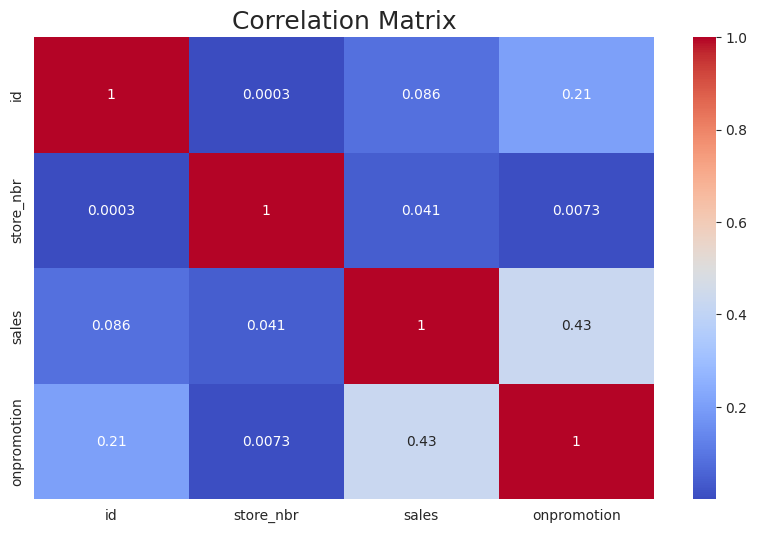

In [ ]:
# ============================================
# CORRELATION MATRIX
# ============================================

numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

plt.figure(figsize=(10,6))

sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix",
          fontsize=18)

plt.show()

**Model XGBoost**

In [ ]:
import pandas as pd
import numpy as np

from xgboost import XGBRegressor

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt

In [ ]:
df['date'] = pd.to_datetime(df['date'])

# Aggregate daily sales
daily_sales = df.groupby('date')['sales'].sum().reset_index()

In [ ]:
# Date features
daily_sales['year'] = daily_sales['date'].dt.year
daily_sales['month'] = daily_sales['date'].dt.month
daily_sales['day'] = daily_sales['date'].dt.day
daily_sales['weekday'] = daily_sales['date'].dt.weekday

# Lag Features
daily_sales['lag_1'] = daily_sales['sales'].shift(1)
daily_sales['lag_7'] = daily_sales['sales'].shift(7)
daily_sales['lag_30'] = daily_sales['sales'].shift(30)

# Rolling Mean Features
daily_sales['rolling_mean_7'] = (
    daily_sales['sales']
    .rolling(window=7)
    .mean()
)

daily_sales['rolling_mean_30'] = (
    daily_sales['sales']
    .rolling(window=30)
    .mean()
)

# Remove null values
daily_sales.dropna(inplace=True)

print(daily_sales.head())

         date          sales  year  month  day  weekday          lag_1  \
30 2013-01-31  271254.217996  2013      1   31        3  281061.127052   
31 2013-02-01  369402.055266  2013      2    1        4  271254.217996   
32 2013-02-02  518887.462705  2013      2    2        5  369402.055266   
33 2013-02-03  486336.820180  2013      2    3        6  518887.462705   
34 2013-02-04  344308.715017  2013      2    4        0  486336.820180   

            lag_7         lag_30  rolling_mean_7  rolling_mean_30  
30  247245.690995    2511.618999   319499.837745    344170.437264  
31  290022.771930  496092.417944   330839.735365    339947.425174  
32  413799.767975  361461.231124   345852.263183    345194.966227  
33  430411.991233  354459.677093   353841.524461    349590.870997  
34  285460.169953  477350.121229   362248.459470    345156.157456  


In [ ]:
X = daily_sales[
    [
        'year',
        'month',
        'day',
        'weekday',
        'lag_1',
        'lag_7',
        'lag_30',
        'rolling_mean_7',
        'rolling_mean_30'
    ]
]

y = daily_sales['sales']

In [ ]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [ ]:
model = XGBRegressor(

    n_estimators=1000,
    learning_rate=0.01,
    max_depth=8,

    subsample=0.8,
    colsample_bytree=0.8,

    objective='reg:squarederror',

    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
predictions = model.predict(X_test)

In [ ]:
r2 = r2_score(y_test, predictions)

mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(
    mean_squared_error(y_test, predictions)
)

print("R2 Score:", r2)

print(f"Accuracy: {r2*100:.2f}%")

print("MAE:", mae)

print("RMSE:", rmse)

R2 Score: 0.6225782146467729
Accuracy: 62.26%
MAE: 75102.1857852695
RMSE: 113853.72990862504


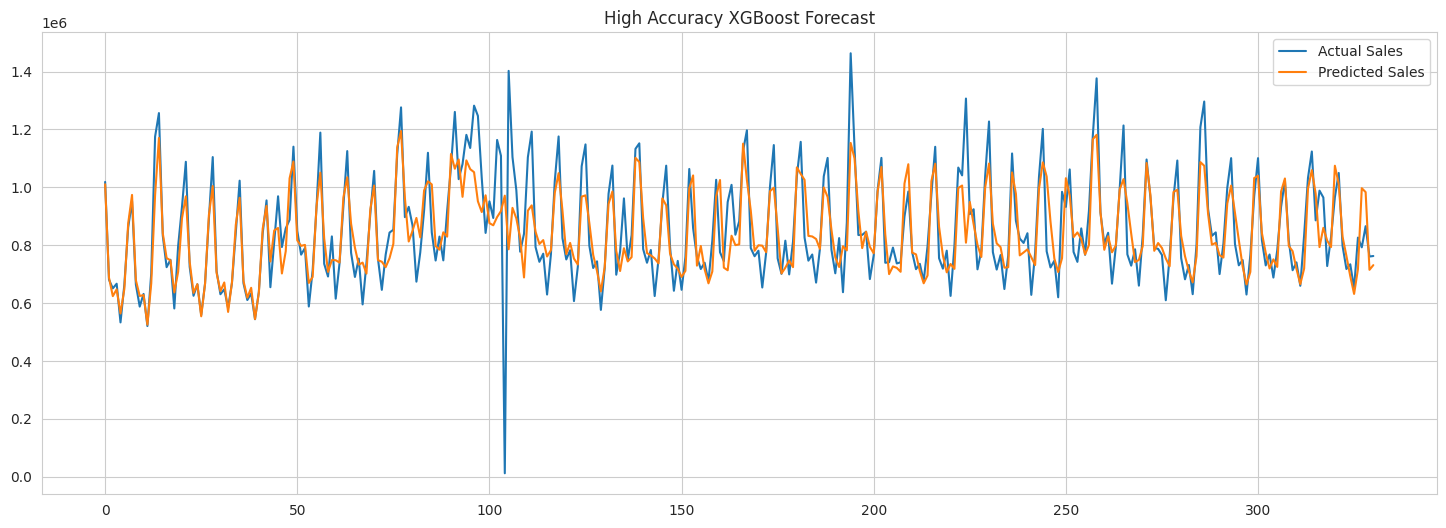

In [ ]:
plt.figure(figsize=(18,6))

plt.plot(y_test.values,
         label='Actual Sales')

plt.plot(predictions,
         label='Predicted Sales')

plt.legend()

plt.title("High Accuracy XGBoost Forecast")

plt.show()

In [ ]:
# ============================================
# XGBOOST ACCURACY
# ============================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

# Predictions
xgb_predictions = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, xgb_predictions)

mse = mean_squared_error(y_test, xgb_predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, xgb_predictions)

# Accuracy Percentage
accuracy = r2 * 100

print("XGBoost Model Performance")
print("----------------------------")

print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

print(f"Accuracy : {accuracy:.2f}%")

XGBoost Model Performance
----------------------------
MAE  : 75102.1857852695
MSE  : 12962671814.106142
RMSE : 113853.72990862504
R2 Score : 0.6225782146467729
Accuracy : 62.26%
